In [2]:
# CELL 1 — verify working

import torch
import torchvision
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

print(" PyTorch version:", torch.__version__)
print(" Torchvision:", torchvision.__version__)
print(" NumPy:", np.__version__)

# Check if GPU is available
if torch.cuda.is_available():
    print(" GPU available:", torch.cuda.get_device_name(0))
else:
    print(" No GPU — using CPU (slower but works)")


 PyTorch version: 2.11.0+cpu
 Torchvision: 0.26.0+cpu
 NumPy: 2.3.5
 No GPU — using CPU (slower but works)


In [3]:
import os

from pathlib import Path

# Repo root: walk up from the notebook's directory until app.py is found.
BASE_PATH = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "app.py").is_file())

KAGGLE_PATH = BASE_PATH / "datasets" / "KAGGLE DATASET" / "Combined Dataset" / "train"
OASIS_PATH  = BASE_PATH / "datasets" / "OASIS DATASET" / "Data"
MODELS_PATH = BASE_PATH / "models"
RESULTS_PATH= BASE_PATH / "results"

for path in [KAGGLE_PATH, OASIS_PATH, MODELS_PATH, RESULTS_PATH]:
    if os.path.exists(path):
        print(f" Found: {path}")
    else:
        print(f"XX NOT FOUND: {path}")

 Found: datasets\KAGGLE DATASET\Combined Dataset\train
 Found: datasets\OASIS DATASET\Data
 Found: models
 Found: results


In [4]:
# CELL 3 — See classes and images 

classes = []
image_counts = {}

for folder_name in os.listdir(KAGGLE_PATH):
    folder_path = os.path.join(KAGGLE_PATH, folder_name)
    
    if os.path.isdir(folder_path):
        images = os.listdir(folder_path)
        image_counts[folder_name] = len(images)
        classes.append(folder_name)
        print(f" {folder_name}: {len(images)} images")

print(f"\nTotal classes: {len(classes)}")
print(f"Total images: {sum(image_counts.values())}")

 Mild Impairment: 2560 images
 Moderate Impairment: 2560 images
 No Impairment: 2560 images
 Very Mild Impairment: 2560 images

Total classes: 4
Total images: 10240


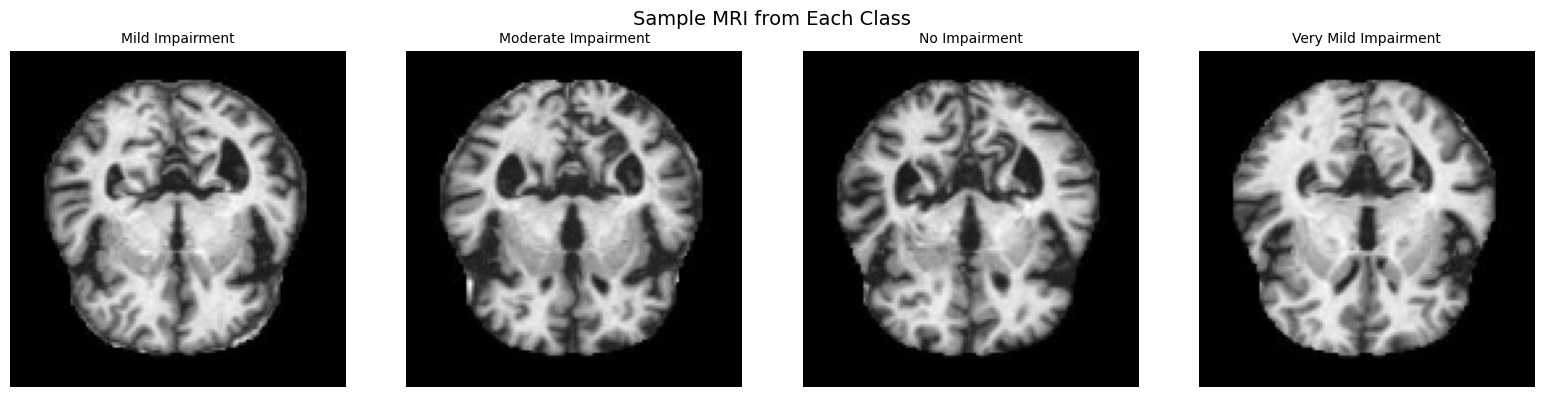

 Sample images shown and saved


In [5]:
# CELL 4 — Visualize one sample

import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, class_name in enumerate(sorted(classes)):
    class_folder = os.path.join(KAGGLE_PATH, class_name)
    first_image = os.listdir(class_folder)[0]
    img_path = os.path.join(class_folder, first_image)
    
    img = Image.open(img_path)
    
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(class_name, fontsize=10)
    axes[idx].axis('off')

plt.suptitle("Sample MRI from Each Class", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'sample_images.png'))
plt.show()

print(" Sample images shown and saved")

In [6]:
# CELL 5 — preprocessing

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(" Preprocessing ready")

 Preprocessing ready


In [7]:
# CELL 6 — Load dataset and split

from torchvision import datasets
from torch.utils.data import DataLoader, random_split

# Load dataset
full_dataset = datasets.ImageFolder(
    root=KAGGLE_PATH,
    transform=train_transform
)

# Class mapping
print("Class mapping:")
for k, v in full_dataset.class_to_idx.items():
    print(f"{v} → {k}")

# Split sizes
total = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

print(f"\nTotal: {total}")
print(f"Train: {train_size}")
print(f"Val:   {val_size}")
print(f"Test:  {test_size}")

# Split
train_data, val_data, test_data = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

print("\n Dataset ready")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Class mapping:
0 → Mild Impairment
1 → Moderate Impairment
2 → No Impairment
3 → Very Mild Impairment

Total: 10240
Train: 7168
Val:   1536
Test:  1536

 Dataset ready
Train batches: 224
Val batches:   48
Test batches:  48
